# Analisis del proyecto — Curso 0 Python (Master en Ciencias Actuariales, UC3M)

Este notebook es el punto central del analisis: importa las funciones definidas en `scripts/`
y las usa para crear la base de datos, cargar los datos, y generar los graficos y estadisticos.

Los scripts NO ejecutan nada por si solos — aqui es donde decidimos que llamar y cuando.

## 0. Imports

Importamos las funciones que necesitamos de cada script, mas las librerias que usaremos
directamente en el notebook (matplotlib para mostrar y guardar graficos).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Carpeta raiz del proyecto: funciona tanto si Jupyter arranca en notebooks/
# como si arranca en la raiz del repositorio.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "scripts").is_dir() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

# Anadimos la raiz al path para poder hacer "from scripts... import ..."
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.init_db import crear_base_de_datos
from scripts.cargar_seguros import cargar_seguros
from scripts.consultar_db import consultar_tabla
from scripts.histograma_edades import histograma
from scripts.correlacion_fumador_hijos import calcular_correlacion, imprimir_resultado


## 1. Crear la base de datos y cargar los datos

Llamamos a las dos funciones de preparacion de datos. No hace falta pasarles ninguna ruta:
usan sus valores por defecto (`data/proyecto.db`, `data/seguros.csv`).

In [2]:
crear_base_de_datos()
cargar_seguros()


Base de datos creada/actualizada en: C:\Users\Daniel\Desktop\Proyecto python\data\proyecto.db
Tabla 'seguros' cargada con 1338 filas en C:\Users\Daniel\Desktop\Proyecto python\data\proyecto.db


1338

## 1b. Consultar la tabla 'alumnos'

Como ejemplo de consulta simple, usamos `consultar_tabla()` para traer la tabla de ejemplo
`alumnos` como un DataFrame de pandas.

In [3]:
df_alumnos = consultar_tabla("alumnos")
df_alumnos


,id,nombre,asignatura,nota
0,1,Daniel,Estadistica Actuarial,8.5
1,2,Laura,Matematica Financiera,9.1
2,3,Marcos,Probabilidad,7.3


## 2. Histograma de edades

Usamos la funcion `histograma()` indicando la columna que queremos ver (`age`) y el ancho
de banda de las barras. La funcion nos devuelve la figura (`fig`) y los ejes (`ax`);
aqui decidimos mostrarla con `plt.show()`.

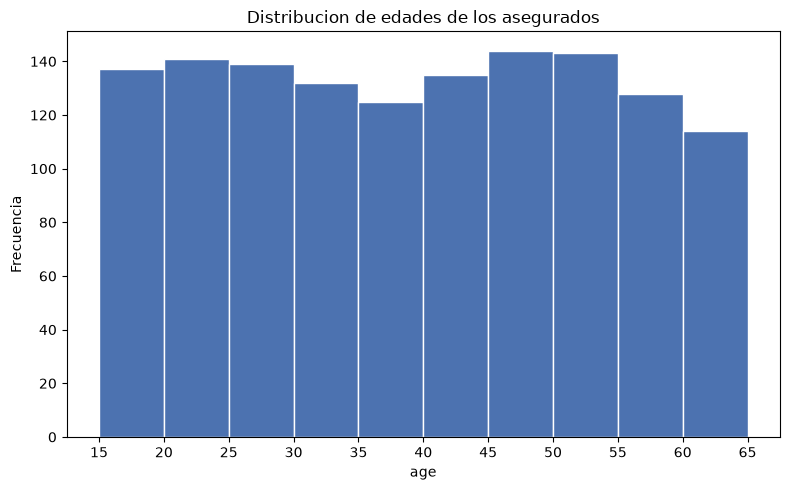

In [4]:
fig, ax = histograma("age", ancho_banda=5, titulo="Distribucion de edades de los asegurados")
plt.show()


## 3. Correlacion entre ser fumador y no tener hijos

Calculamos la correlacion para todos los registros, y luego filtrando por sexo, para comparar.

In [5]:
resultado_todos = calcular_correlacion()
imprimir_resultado("Todos los registros", resultado_todos)

resultado_mujeres = calcular_correlacion(sexo="female")
imprimir_resultado("Solo mujeres", resultado_mujeres)

resultado_hombres = calcular_correlacion(sexo="male")
imprimir_resultado("Solo hombres", resultado_hombres)


--- Todos los registros (n = 1338) ---
Tabla de contingencia (filas=fumador, columnas=sin_hijos):
sin_hijos    0    1
fumador            
0          605  459
1          159  115

Coeficiente de correlacion (fumador vs sin_hijos): -0.0095
Test chi-cuadrado: chi2 = 0.0784, p-valor = 0.7795
=> No hay evidencia suficiente de asociacion (p >= 0.05).

--- Solo mujeres (n = 662) ---
Tabla de contingencia (filas=fumador, columnas=sin_hijos):
sin_hijos    0    1
fumador            
0          311  236
1           62   53

Coeficiente de correlacion (fumador vs sin_hijos): 0.0225
Test chi-cuadrado: chi2 = 0.2256, p-valor = 0.6348
=> No hay evidencia suficiente de asociacion (p >= 0.05).

--- Solo hombres (n = 676) ---
Tabla de contingencia (filas=fumador, columnas=sin_hijos):
sin_hijos    0    1
fumador            
0          294  223
1           97   62

Coeficiente de correlacion (fumador vs sin_hijos): -0.0356
Test chi-cuadrado: chi2 = 0.6933, p-valor = 0.4051
=> No hay evidencia suficiente d

## 4. Guardar todos los graficos en un unico PDF

En vez de ir guardando cada grafico como un PNG suelto, los juntamos todos en un solo
PDF (una pagina por grafico) usando `PdfPages`. Aqui generamos dos histogramas de ejemplo
(edad y bmi) y los grapamos en `data/graficos.pdf`.

In [6]:
PDF_PATH = DATA_DIR / "graficos.pdf"

with PdfPages(PDF_PATH) as pdf:
    fig1, ax1 = histograma("age", ancho_banda=5, titulo="Distribucion de edades")
    pdf.savefig(fig1)
    plt.close(fig1)

    fig2, ax2 = histograma("bmi", ancho_banda=2, titulo="Distribucion de BMI")
    pdf.savefig(fig2)
    plt.close(fig2)

print(f"Graficos guardados en: {PDF_PATH}")


Graficos guardados en: c:\Users\Daniel\Desktop\Proyecto python\data\graficos.pdf
